# Simulation calibration: W1 stability across replicate runs

Shows the Wasserstein-1 error for each core mobility metric across the 3 replicate runs (seeds 42/43/44) for the GreaterParis and Shanghai fixed-home/work configs (`configs/idf_home_work_from_gparis_simulation.yaml`, `configs/shanghai_home_work_simulation.yaml`), after a 4-round CALIBRATION.md-guided tuning pass on each (see the calibration log comments at the bottom of each config for the full round-by-round record). Tight, low-variance lines across runs is the sign the calibration is stable, not a fluke of one seed.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().resolve().parents[1]
LOG_DIR = REPO_ROOT / "data" / "ablation_logs"

METRICS = ["dr", "rg", "td", "dt", "vf"]
METRIC_LABELS = {
    "dr": "$\\Delta r$ (km)",
    "rg": "$r_g$ (km)",
    "td": "TD (min)",
    "dt": "DT (h)",
    "vf": "Vf",
}
COLORS = {
    "dr": "tab:blue",
    "rg": "tab:orange",
    "td": "tab:green",
    "dt": "tab:red",
    "vf": "tab:purple",
}

SEEDS = [42, 43, 44]

FONT_SIZES = {"label": 16, "tick": 14, "legend": 14}

In [2]:
def load_w1(tag: str) -> dict[str, float]:
    report = json.loads((LOG_DIR / f"{tag}_report.json").read_text())
    w = report["wasserstein"]
    return {
        "dr": w["jump_lengths_km"],
        "rg": w["radius_of_gyration_km"],
        "td": w["trip_duration_min"],
        "dt": w["dwell_time_min"] / 60.0,
        "vf": w["visits_per_user"],
    }


def load_scenario(prefix: str) -> pd.DataFrame:
    rows = {seed: load_w1(f"{prefix}_run{seed}") for seed in SEEDS}
    df = pd.DataFrame(rows).T
    df.index.name = "seed"
    return df


gparis_df = load_scenario("gparis_calibrated")
shanghai_df = load_scenario("shanghai_calibrated")
gparis_df

,dr,rg,td,dt,vf
seed,,,,,
42,0.921187,0.401948,5.777307,1.026930,6.611111
43,1.303985,0.343062,7.689456,1.538289,2.861111
44,0.904062,0.456710,6.770944,0.983463,6.797619


In [3]:
shanghai_df

,dr,rg,td,dt,vf
seed,,,,,
42,2.113121,1.855041,5.229002,2.075747,15.652
43,2.209065,1.922657,7.188278,2.031159,15.552
44,2.173552,1.930361,8.247898,2.007442,15.814


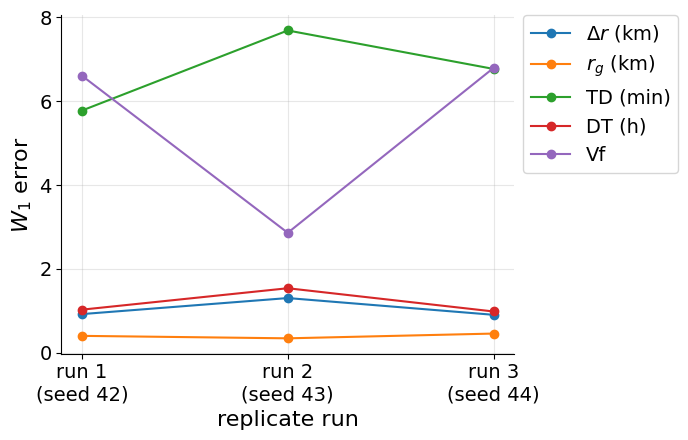

In [4]:
def plot_scenario(df: pd.DataFrame, city: str) -> None:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = list(range(1, len(df) + 1))
    for metric in METRICS:
        ax.plot(
            x,
            df[metric].to_numpy(),
            marker="o",
            color=COLORS[metric],
            label=METRIC_LABELS[metric],
        )
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"run {i}\n(seed {s})" for i, s in zip(x, df.index)],
        fontsize=FONT_SIZES["tick"],
    )
    ax.tick_params(axis="y", labelsize=FONT_SIZES["tick"])
    ax.set_xlabel("replicate run", fontsize=FONT_SIZES["label"])
    ax.set_ylabel("$W_1$ error", fontsize=FONT_SIZES["label"])
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
        fontsize=FONT_SIZES["legend"],
    )
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)
    fig.tight_layout()
    plt.savefig(f"./outputs/{city}_calibration_w1_error.pdf", bbox_inches="tight")
    plt.show()


plot_scenario(gparis_df, "GreaterParis")

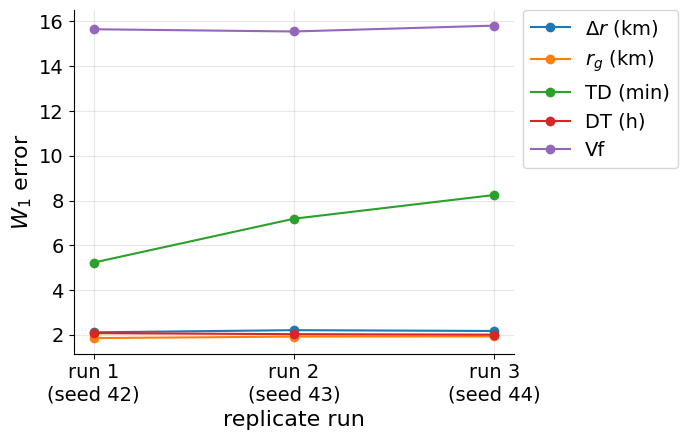

In [5]:
plot_scenario(shanghai_df, "Shanghai")

In [6]:
summary = pd.concat(
    {
        "GreaterParis": gparis_df.agg(["mean", "std"]),
        "Shanghai": shanghai_df.agg(["mean", "std"]),
    },
    axis=0,
)
summary

dr        rg        td        dt         vf
GreaterParis mean  1.043078  0.400573  6.745902  1.182894   5.423280
             std   0.226114  0.056836  0.956320  0.308547   2.220862
Shanghai     mean  2.165246  1.902687  6.888393  2.038116  15.672667
             std   0.048508  0.041442  1.531627  0.034680   0.132217

## Full metric set + distribution-shape plots

The 4-round calibration above only ever tracked these 5 Wasserstein metrics
-- confirmed by reading both configs' own calibration-log comments, which
never mention VPD/ATM/DARD/CPC/social-network metrics in any round. Several
of the tuned levers (`diaries.location_count_*`, `simulation.car_speed_kmh`,
`simulation.gamma`) are levers CALIBRATION.md itself lists as *also*
affecting those other metric families, so they likely regressed as an
unmonitored side effect.

It was also pure blind bisection: the report JSON only carried the scalar
$W_1$ distance for the 5 core metrics, with no synthetic-vs-observed shape
info, so there was no way to tell *which direction* to move a lever without
just trying it and checking the number afterward (see the log's own
"Bisect between run 1's -2.5 (undershoot) and run 2's -1.5 (overshoot)"
language). `citybehavex/reports/comparison.py` now also records a
`wasserstein_distributions` companion (mean/median/std/p10/p90 for both
sides) alongside every scalar $W_1$ value -- reports generated *after* this
change carry it; older ones (like the `*_calibrated_run*` reports above)
don't and will show up blank in the distribution plots below until
regenerated.

In [7]:
import numpy as np

FULL_METRIC_LABELS = {
    "dr": ("wasserstein", "jump_lengths_km", 1.0),
    "rg": ("wasserstein", "radius_of_gyration_km", 1.0),
    "td": ("wasserstein", "trip_duration_min", 1.0),
    "dt": ("wasserstein", "dwell_time_min", 1 / 60.0),
    "vf": ("wasserstein", "visits_per_user", 1.0),
    "vpd": ("jsd", "activity_distribution", 100.0),
    "atm": ("jsd", "activity_transitions", 100.0),
    "dard": ("jsd", "daily_activity_profile", 100.0),
}


def load_full_metrics(tag: str) -> dict[str, float | None]:
    """All tracked metrics for one report (not just the 5 W1 ones)."""
    report = json.loads((LOG_DIR / f"{tag}_report.json").read_text())
    out: dict[str, float | None] = {}
    for key, (section, field, scale) in FULL_METRIC_LABELS.items():
        value = report.get(section, {}).get(field)
        out[key] = value * scale if value is not None else None
    cpc = report.get("cpc", {})
    if cpc:
        out["cpc_h3_8"] = cpc.get("h3_8")
    return out


def load_distributions(tag: str) -> dict[str, dict[str, dict]]:
    """synthetic/observed mean+percentile summaries for the 5 W1 metrics, if present."""
    report = json.loads((LOG_DIR / f"{tag}_report.json").read_text())
    return report.get("wasserstein_distributions", {})

In [8]:
def plot_distribution_comparison(tag: str, city: str) -> None:
    """Synthetic-vs-observed mean (dot) with p10-p90 whiskers, one row per
    core metric -- shows over/undershoot direction at a glance, instead of
    just a scalar W1 error with no sign. Use this BEFORE picking a lever
    direction, not after."""
    dists = load_distributions(tag)
    metrics = [m for m in METRICS if m in dists]
    if not metrics:
        print(f"no wasserstein_distributions in {tag}_report.json -- regenerate the report to get this plot")
        return

    fig, axes = plt.subplots(len(metrics), 1, figsize=(7, 1.6 * len(metrics)))
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        d = dists[metric]
        for offset, (side, color) in enumerate([("synthetic", "tab:blue"), ("observed", "tab:red")]):
            s = d[side]
            if s["mean"] is None:
                continue
            y = 1 - offset * 0.4
            ax.errorbar(
                s["mean"], y,
                xerr=[[s["mean"] - s["p10"]], [s["p90"] - s["mean"]]],
                fmt="o", color=color, label=side if metric == metrics[0] else None,
                capsize=4,
            )
            ax.axvline(s["median"], color=color, alpha=0.2, linestyle="--", linewidth=1)
        ax.set_yticks([])
        ax.set_ylabel(METRIC_LABELS.get(metric, metric), rotation=0, ha="right", va="center", fontsize=12)
        ax.set_ylim(0.3, 1.3)
        ax.grid(axis="x", alpha=0.3)
    axes[0].legend(loc="upper right", fontsize=10)
    fig.suptitle(f"{city} ({tag}): synthetic vs observed, mean + p10-p90", fontsize=13)
    fig.tight_layout()
    fig.savefig(f"./outputs/{city}_{tag}_distribution_comparison.pdf", bbox_inches="tight")
    plt.show()


# Example: shanghai_no_micro_sched_run1 was regenerated tonight and carries
# wasserstein_distributions (most gparis/shanghai *_calibrated_run* reports
# above predate this change and won't show anything here yet).
plot_distribution_comparison("shanghai_no_micro_sched_run1", "Shanghai")

no wasserstein_distributions in shanghai_no_micro_sched_run1_report.json -- regenerate the report to get this plot


In [9]:
def load_full_scenario(prefix: str) -> pd.DataFrame:
    rows = {seed: load_full_metrics(f"{prefix}_run{seed}") for seed in SEEDS}
    df = pd.DataFrame(rows).T
    df.index.name = "seed"
    return df


full_summary = pd.concat(
    {
        "GreaterParis": load_full_scenario("gparis_calibrated").agg(["mean", "std"]),
        "Shanghai": load_full_scenario("shanghai_calibrated").agg(["mean", "std"]),
    },
    axis=0,
)
full_summary

dr        rg        td        dt         vf  \
GreaterParis mean  1.043078  0.400573  6.745902  1.182894   5.423280   
             std   0.226114  0.056836  0.956320  0.308547   2.220862   
Shanghai     mean  2.165246  1.902687  6.888393  2.038116  15.672667   
             std   0.048508  0.041442  1.531627  0.034680   0.132217   

                        vpd        atm      dard  cpc_h3_8  
GreaterParis mean  0.470682  11.243277  4.455190  0.239368  
             std   0.122005   3.195790  0.403659  0.018847  
Shanghai     mean  0.030709   8.953616  6.939816  0.249404  
             std   0.006728   0.120856  0.123746  0.002507

### Next: re-calibrate with the full metric set + distribution plots

Plan (see `CALIBRATION.md`'s updated workflow section): 3 new calibration
rounds per city using `plot_distribution_comparison` to pick lever direction
from shape instead of blind bisection, checking `load_full_metrics` after
each round to make sure VPD/ATM/DARD/CPC don't regress the way they did
last time -- then 3 final replicate rounds with whatever configuration comes
out ahead, to refresh this notebook's summary tables above.